In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
import os
from PIL import Image

def load_images(folder):
    images = []

    for digit in range(10):
        digit_folder = os.path.join(folder, str(digit))

        for filename in os.listdir(digit_folder):
            img_path = os.path.join(digit_folder, filename)

            img = Image.open(img_path).convert("L")
            img = np.array(img)

            images.append(img)

    return np.array(images)


train_path = "mnist_png/training"
test_path = "mnist_png/testing"

x_train = load_images(train_path)
x_test = load_images(test_path)

In [3]:
print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)

Training shape: (60000, 28, 28)
Testing shape : (10000, 28, 28)


## Image Normalization

The MNIST images contain pixel intensity values ranging from 0 to 255. The images are normalized to the range 0 to 1 to improve the stability and efficiency of neural network training.

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


## Visualize : Clean MNIST Images

A few images from the training dataset are visualized to understand the original clean images before artificial noise is introduced.

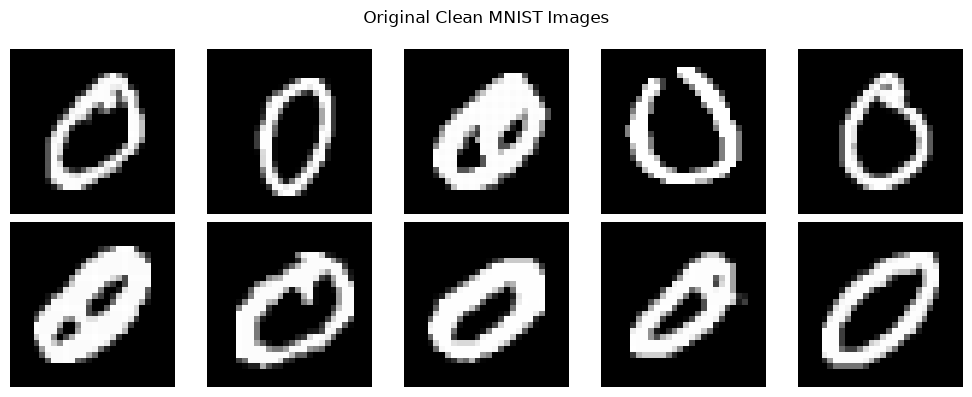

In [5]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")

plt.suptitle("Original Clean MNIST Images")
plt.tight_layout()
plt.show()

## Adding Noise to Images

To train the autoencoder for image denoising, Gaussian noise is artificially added to the clean MNIST images.

The noisy images will be used as input to the autoencoder, while the original clean images will serve as the target output. The model will learn to remove noise and reconstruct the original images.

In [6]:
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

## Clean vs Noisy Images

The following visualization compares the original MNIST images with their noisy versions. These noisy images will be provided as input to the autoencoder during training.

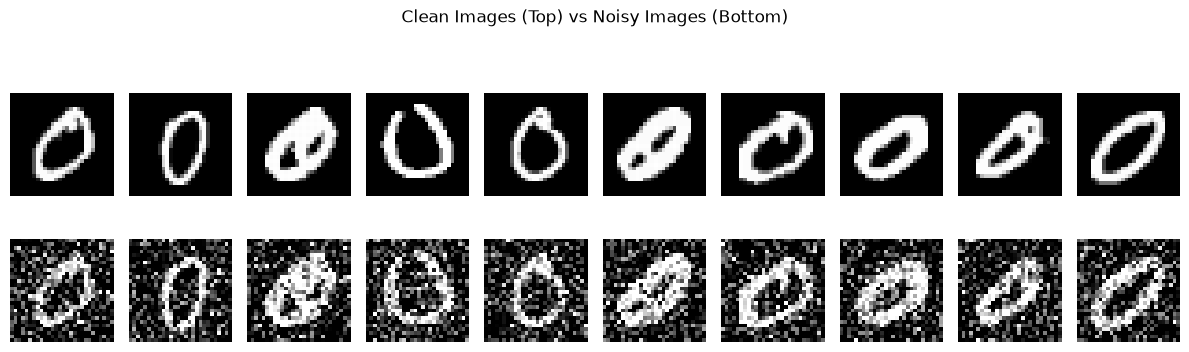

In [7]:
plt.figure(figsize=(12, 4))

for i in range(10):

    # clean image
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")

    # noisy image
    plt.subplot(2, 10, i + 11)
    plt.imshow(x_train_noisy[i], cmap="gray")
    plt.axis("off")

plt.suptitle("Clean Images (Top) vs Noisy Images (Bottom)")
plt.tight_layout()
plt.show()

## Building the Convolutional Autoencoder

A convolutional autoencoder consists of two main components:

- **Encoder:** Extracts important features from the noisy image and compresses them into a lower-dimensional representation.
- **Decoder:** Uses the compressed representation to reconstruct the original clean image.

The model is trained by providing noisy images as input and clean images as the target output.

In [8]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

x_train_noisy = np.expand_dims(x_train_noisy, axis=-1)
x_test_noisy = np.expand_dims(x_test_noisy, axis=-1)

print("Clean training shape:", x_train.shape)
print("Noisy training shape:", x_train_noisy.shape)

Clean training shape: (60000, 28, 28, 1)
Noisy training shape: (60000, 28, 28, 1)


In [9]:
from tensorflow.keras import layers, models

autoencoder = models.Sequential([

    # encoder
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    layers.Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2),
        padding="same"
    ),

    # decoder
    layers.Conv2D(
        16,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.UpSampling2D((2, 2)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.UpSampling2D((2, 2)),

    # reconstructed image
    layers.Conv2D(
        1,
        (3, 3),
        activation="sigmoid",
        padding="same"
    )
])

In [10]:
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Autoencoder

The autoencoder is trained using noisy images as input and the corresponding clean images as target output.

The Adam optimizer is used for optimization, while binary cross-entropy measures the reconstruction error between the original and reconstructed images.

In [11]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [12]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - loss: 0.1697 - val_loss: 0.1097
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - loss: 0.1058 - val_loss: 0.1010
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.1000 - val_loss: 0.0981
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - loss: 0.0973 - val_loss: 0.0955
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 71ms/step - loss: 0.0954 - val_loss: 0.0937
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - loss: 0.0938 - val_loss: 0.0923
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.0928 - val_loss: 0.0915
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - loss: 0.0921 - val_loss: 0.0909
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - loss: 0.0915 - val_loss: 0.0903
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.0910 - val_loss: 0.0899


## Training and Validation Loss

The training and validation loss curves are plotted to analyze the learning behavior of the autoencoder. A decreasing loss indicates that the model is improving its ability to reconstruct clean images from noisy inputs.

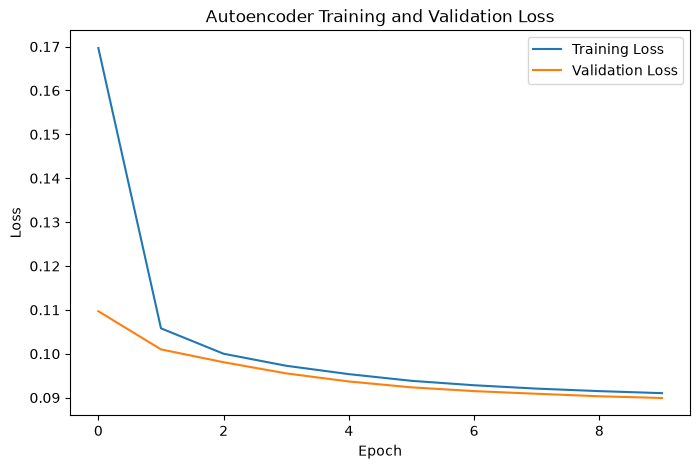

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.show()

## Image Denoising using the Trained Autoencoder

The trained autoencoder is used to reconstruct clean images from noisy test samples. The reconstructed images are then compared with the noisy inputs and original clean images to visually evaluate the denoising performance.

In [14]:
denoised_images = autoencoder.predict(x_test_noisy)

print("Denoised images shape:", denoised_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
Denoised images shape: (10000, 28, 28, 1)


## Denoising Results

The performance of the trained autoencoder is evaluated visually by comparing the noisy input images, reconstructed denoised images, and original clean images.

- **Top Row:** Noisy input images
- **Middle Row:** Denoised images reconstructed by the autoencoder
- **Bottom Row:** Original clean images

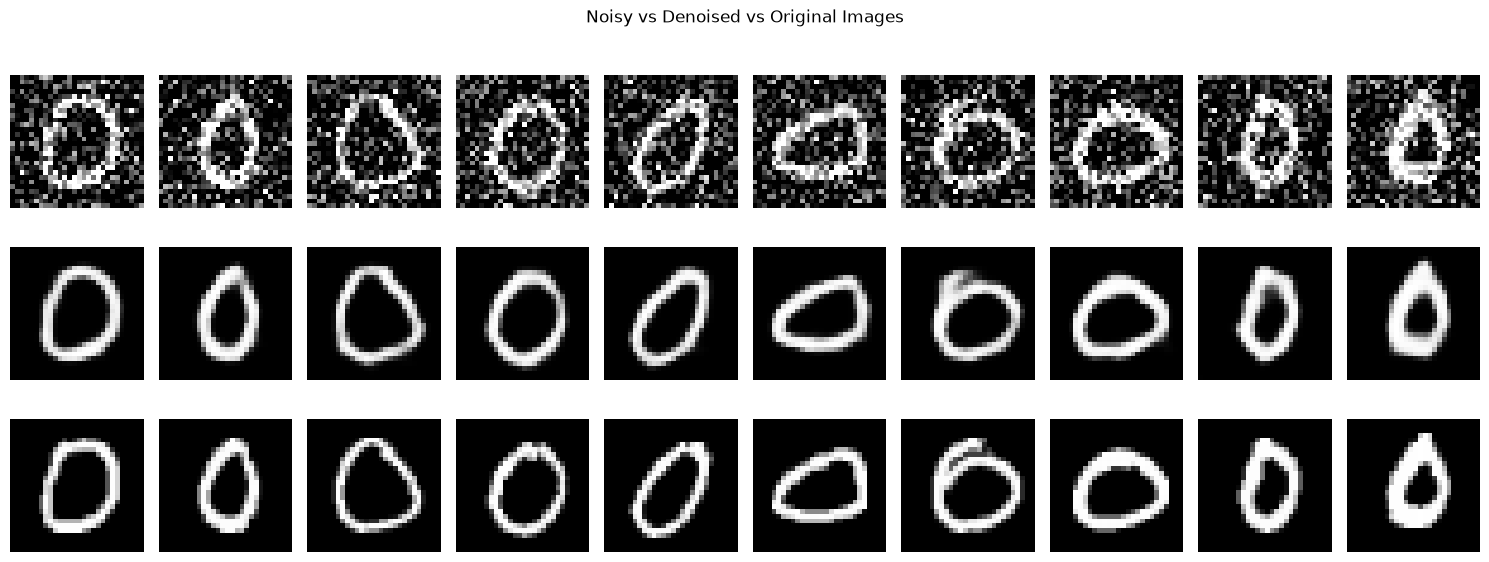

In [15]:
n = 10

plt.figure(figsize=(15, 6))

for i in range(n):

    # noisy images
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

    # denoised images
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].squeeze(), cmap="gray")
    plt.axis("off")

    # original clean images
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Noisy vs Denoised vs Original Images")
plt.tight_layout()
plt.show()

### Observation

- The noisy input images contain significant random noise, making the digit shapes difficult to distinguish.
- The trained autoencoder successfully removes most of the noise and reconstructs recognizable digit shapes.
- The reconstructed images closely resemble the original clean images, although some edges appear slightly smoother or blurred.
- This demonstrates that the autoencoder successfully learned important visual features of the MNIST images instead of simply reproducing the noisy input.

## Denoising Results Across Different Digits

To evaluate the generalization ability of the autoencoder, samples from different digit classes (0–9) are selected and compared.

- **Top Row:** Noisy input images
- **Middle Row:** Denoised images reconstructed by the autoencoder
- **Bottom Row:** Original clean images

This visualization demonstrates whether the autoencoder can effectively remove noise across different handwritten digit patterns.

In [16]:
test_labels = []

for digit in range(10):
    digit_folder = os.path.join(test_path, str(digit))
    count = len(os.listdir(digit_folder))
    test_labels.extend([digit] * count)

test_labels = np.array(test_labels)

print(test_labels.shape)

(10000,)


In [17]:
sample_indices = []

for digit in range(10):
    index = np.where(test_labels == digit)[0][0]
    sample_indices.append(index)

print(sample_indices)

[np.int64(0), np.int64(980), np.int64(2115), np.int64(3147), np.int64(4157), np.int64(5139), np.int64(6031), np.int64(6989), np.int64(8017), np.int64(8991)]


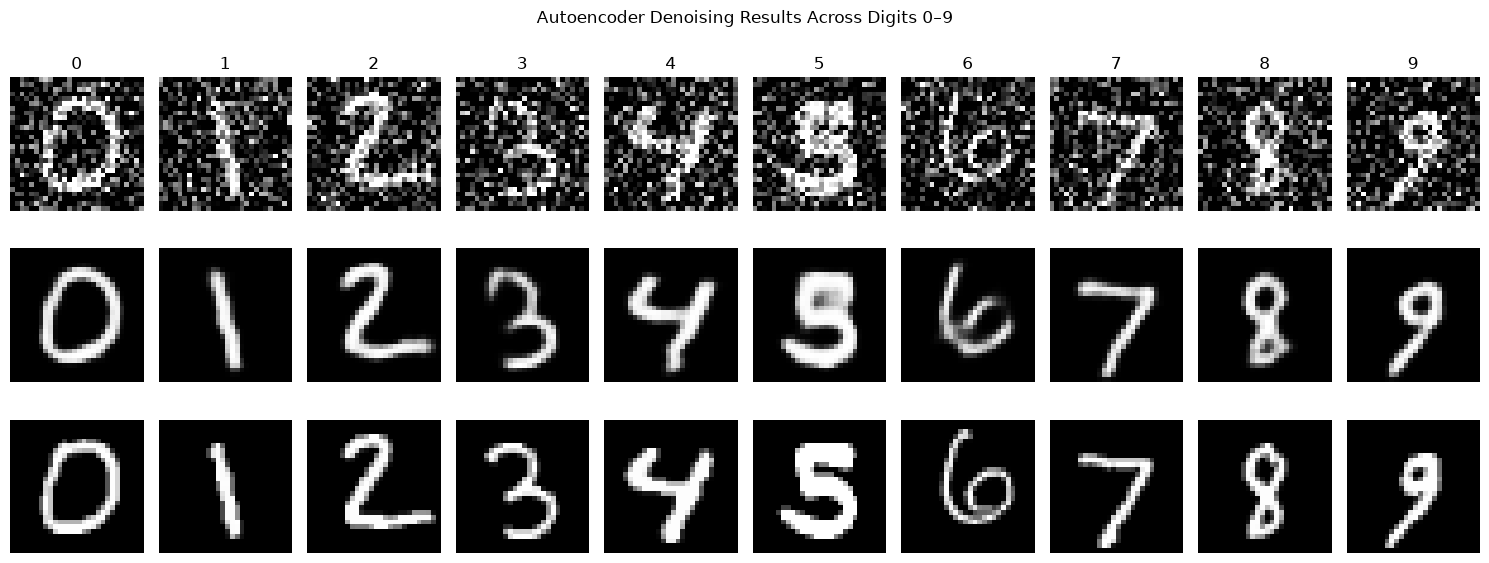

In [18]:
plt.figure(figsize=(15, 6))

for i, idx in enumerate(sample_indices):

    # noisy
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test_noisy[idx].squeeze(), cmap="gray")
    plt.title(str(i))
    plt.axis("off")

    # denoised
    plt.subplot(3, 10, i + 11)
    plt.imshow(denoised_images[idx].squeeze(), cmap="gray")
    plt.axis("off")

    # original
    plt.subplot(3, 10, i + 21)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Autoencoder Denoising Results Across Digits 0–9")
plt.tight_layout()
plt.show()

## Model Evaluation

The denoising performance of the autoencoder is quantitatively evaluated using Mean Squared Error (MSE).

A lower MSE indicates that the reconstructed images are closer to the original clean images.

In [19]:
from sklearn.metrics import mean_squared_error

noisy_mse = mean_squared_error(
    x_test.flatten(),
    x_test_noisy.flatten()
)

denoised_mse = mean_squared_error(
    x_test.flatten(),
    denoised_images.flatten()
)

print("Noisy Images MSE   :", noisy_mse)
print("Denoised Images MSE:", denoised_mse)

Noisy Images MSE   : 0.07963928960011953
Denoised Images MSE: 0.00910444650799036


### Observation

- The noisy test images produced an MSE of **0.07964** compared with the original clean images.
- After passing the noisy images through the trained autoencoder, the MSE decreased to **0.00910**.
- This represents approximately an **88.6% reduction in reconstruction error**.
- The significant decrease in MSE confirms that the autoencoder successfully learned to remove noise while preserving the important structural features of the handwritten digits.
- The quantitative results are consistent with the visual results, where the reconstructed images appeared significantly cleaner than the noisy inputs.

# Conclusion

In this project, a Convolutional Autoencoder was developed to remove noise from handwritten digit images from the MNIST dataset.

Artificial Gaussian noise was added to the original images, and the autoencoder was trained using noisy images as input and clean images as the reconstruction target.

The encoder learned a compressed representation containing important visual features, while the decoder reconstructed cleaner versions of the corrupted images.

The experimental results showed that:

- The autoencoder successfully removed a significant amount of noise from the input images.
- Reconstructed images closely resembled the original handwritten digits.
- Training and validation loss decreased consistently during training.
- The model generalized well across different digit classes from 0 to 9.
- The reconstruction error of the denoised images was lower than that of the noisy images.

Overall, this project demonstrates the effectiveness of autoencoders for image denoising and provides practical understanding of representation learning, image reconstruction, and unsupervised deep learning.